# Down Syndrome Model Selection

### Common Imports

In [3]:
import pickle as pkl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from imblearn.over_sampling import BorderlineSMOTE, SMOTE

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM

from xgboost import XGBClassifier

from keras.models import Sequential
from keras.layers import Dense

import tensorflow as tf

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

I0000 00:00:1778946417.514791  142095 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778946417.518656  142095 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778946417.977740  142095 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778946421.103944  142095 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

### Load Data

In [4]:
df = pkl.load(open("../../../data/2021/processed/down_syndrome/cleaned_df.pkl", "rb"))

### Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["target"]),
    df["target"],
    test_size=0.2,
    random_state=14,
    stratify=df["target"],
)

Because our data is highly imbalanced, we'll try using SMOTE to oversample.

In [6]:
sm = SMOTE(random_state=14)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [7]:
bsm = BorderlineSMOTE(random_state=14)
X_train_bsm, y_train_bsm = bsm.fit_resample(X_train, y_train)

### Data Transformation

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["mothers_single_year_age", "fathers_combined_age"])
    ]
)

preprocessor.fit(X_train, y_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

In [9]:
pkl.dump(preprocessor, open("../../../models/down_syndrome/preprocessor.pkl", "wb"))

In [10]:
X_train_prepared = preprocessor.transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

X_train_sm_prepared = preprocessor.transform(X_train_sm)
X_test_sm_prepared = preprocessor.transform(X_test)

X_train_bsm_prepared = preprocessor.transform(X_train_bsm)
X_test_bsm_prepared = preprocessor.transform(X_test)

### Logistic Regression Model

In [9]:
log_reg = LogisticRegression(random_state=14)

log_reg.fit(X_train_prepared, y_train)

pred_log_reg = log_reg.predict(X_test_prepared)

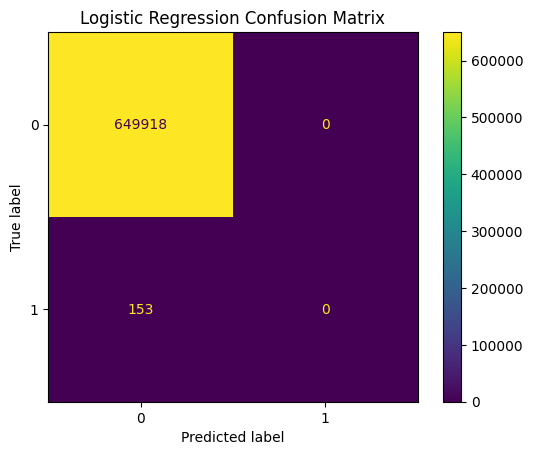

In [10]:
cm_log_reg = confusion_matrix(y_test, pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg)
disp_log_reg.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [11]:
log_reg_sm = LogisticRegression(random_state=14)
log_reg_sm.fit(X_train_sm_prepared, y_train_sm)
pred_log_reg_sm = log_reg_sm.predict(X_test_sm_prepared)

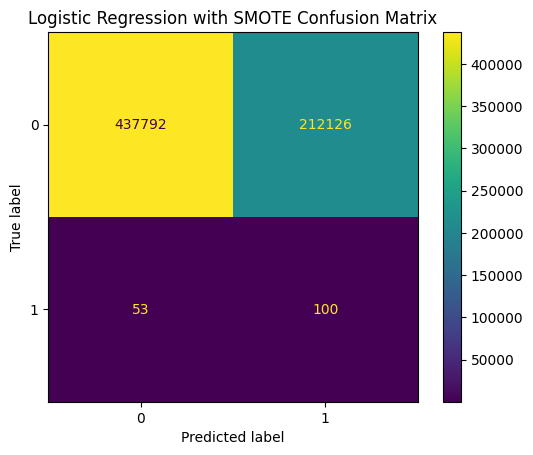

In [12]:
cm_log_reg_sm = confusion_matrix(y_test, pred_log_reg_sm)
disp_log_reg_sm = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg_sm)
disp_log_reg_sm.plot()
plt.title("Logistic Regression with SMOTE Confusion Matrix")
plt.show()

In [13]:
log_reg_bsm = LogisticRegression(random_state=14)
log_reg_bsm.fit(X_train_bsm_prepared, y_train_bsm)
pred_log_reg_bsm = log_reg_bsm.predict(X_test_bsm_prepared)

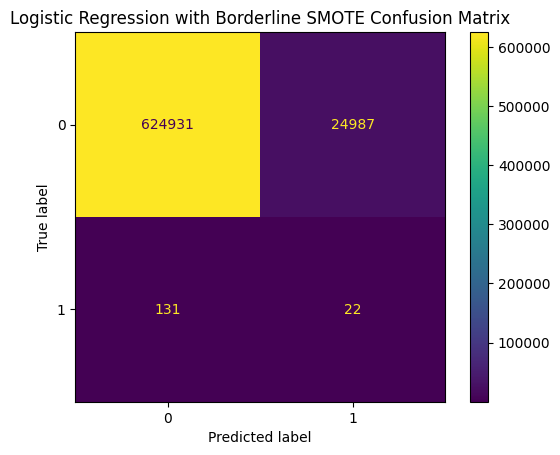

In [14]:
cm_log_reg_bsm = confusion_matrix(y_test, pred_log_reg_bsm)
disp_log_reg_bsm = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg_bsm)
disp_log_reg_bsm.plot()
plt.title("Logistic Regression with Borderline SMOTE Confusion Matrix")
plt.show()

In [15]:
log_reg_f1_score = f1_score(y_test, pred_log_reg)
log_reg_sm_f1_score = f1_score(y_test, pred_log_reg_sm)
log_reg_bsm_f1_score = f1_score(y_test, pred_log_reg_bsm)
print(f"Logistic Regression F1 Score: {log_reg_f1_score:.4f}")
print(f"Logistic Regression with SMOTE F1 Score: {log_reg_sm_f1_score:.4f}")
print(f"Logistic Regression with Borderline SMOTE F1 Score: {log_reg_bsm_f1_score:.4f}")

Logistic Regression F1 Score: 0.0000
Logistic Regression with SMOTE F1 Score: 0.0009
Logistic Regression with Borderline SMOTE F1 Score: 0.0017


### Random Forest Classifier

In [ ]:
rfc = RandomForestClassifier(random_state=14, n_estimators=10, max_depth=5)

rfc.fit(X_train_prepared, y_train)

pred_rfc = rfc.predict(X_test_prepared)

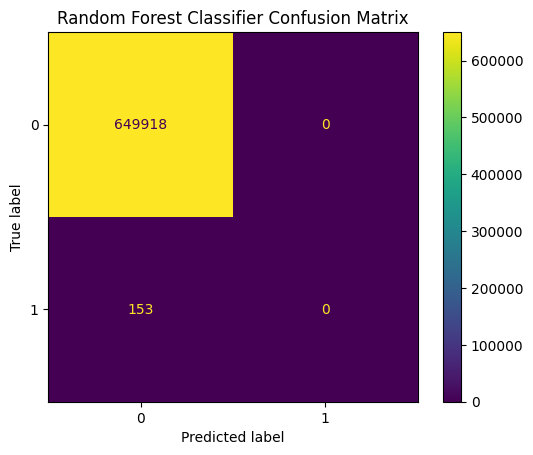

In [17]:
cm_rfc = confusion_matrix(y_test, pred_rfc)
disp_rfc = ConfusionMatrixDisplay(confusion_matrix=cm_rfc)
disp_rfc.plot()
plt.title("Random Forest Classifier Confusion Matrix")
plt.show()

In [ ]:
rfc_sm = RandomForestClassifier(random_state=14, n_estimators=10, max_depth=5)
rfc_sm.fit(X_train_sm_prepared, y_train_sm)
pred_rfc_sm = rfc_sm.predict(X_test_sm_prepared)

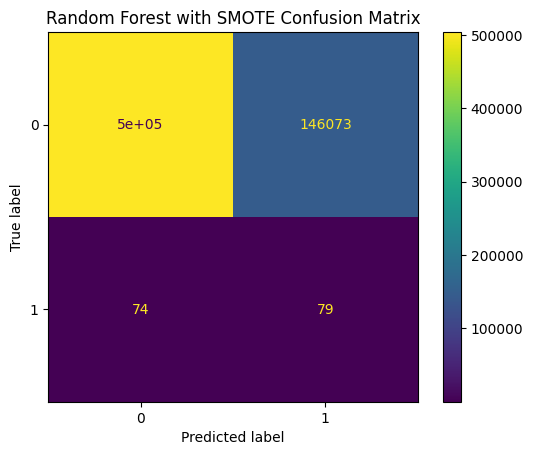

In [19]:
cm_rfc_sm = confusion_matrix(y_test, pred_rfc_sm)
disp_rfc_sm = ConfusionMatrixDisplay(confusion_matrix=cm_rfc_sm)
disp_rfc_sm.plot()
plt.title("Random Forest with SMOTE Confusion Matrix")
plt.show()

In [20]:
rfc_bsm = RandomForestClassifier(random_state=14, n_estimators=10, max_depth=5)
rfc_bsm.fit(X_train_bsm_prepared, y_train_bsm)
pred_rfc_bsm = rfc_bsm.predict(X_test_bsm_prepared)

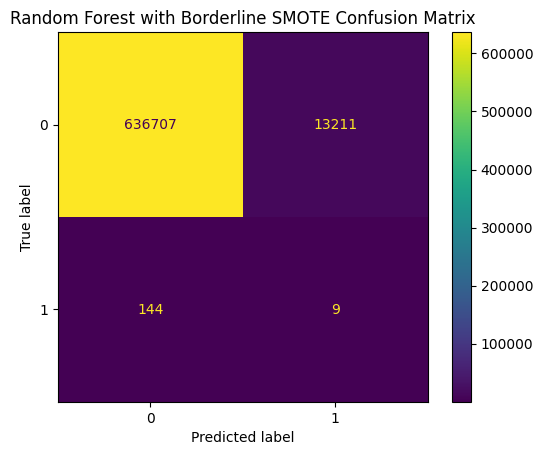

In [21]:
cm_rfc_bsm = confusion_matrix(y_test, pred_rfc_bsm)
disp_rfc_bsm = ConfusionMatrixDisplay(confusion_matrix=cm_rfc_bsm)
disp_rfc_bsm.plot()
plt.title("Random Forest with Borderline SMOTE Confusion Matrix")
plt.show()

In [22]:
rfc_f1_score = f1_score(y_test, pred_rfc)
rfc_sm_f1_score = f1_score(y_test, pred_rfc_sm)
rfc_bsm_f1_score = f1_score(y_test, pred_rfc_bsm)
print(f"Random Forest Classifier F1 Score: {rfc_f1_score:.4f}")
print(f"Random Forest with SMOTE F1 Score: {rfc_sm_f1_score:.4f}")
print(f"Random Forest with Borderline SMOTE F1 Score: {rfc_bsm_f1_score:.4f}")

Random Forest Classifier F1 Score: 0.0000
Random Forest with SMOTE F1 Score: 0.0011
Random Forest with Borderline SMOTE F1 Score: 0.0013


### One-Class SVM

In [9]:
svm = OneClassSVM(gamma="auto", kernel="rbf", nu=0.01)
svm.fit(X_train_prepared[y_train == 0][0:150000, :])

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"nu nu: float, default=0.5An upper bound on the fraction of trainingerrors and a lower bound of the fraction of supportvectors. Should be in the interval (0, 1]. By default 0.5will be taken.",0.01
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [10]:
pred_svm = svm.predict(X_test_prepared)
pred_svm = [1 if i == -1 else 0 for i in pred_svm]

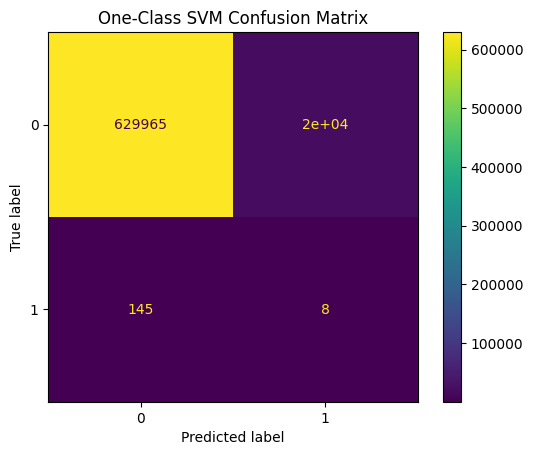

In [11]:
cm_svm = confusion_matrix(y_test, pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot()
plt.title("One-Class SVM Confusion Matrix")
plt.show()

In [12]:
svm_f1_score = f1_score(y_test, pred_svm)
print(f"One-Class SVM F1 Score: {svm_f1_score:.4f}")

One-Class SVM F1 Score: 0.0008


### Local Outlier Factor

In [11]:
lof = LocalOutlierFactor(novelty=True, n_neighbors=20, contamination=0.01)

lof.fit(X_train_prepared[:500000, :])
pred_lof = lof.predict(X_test_prepared)
pred_lof = [1 if i == -1 else 0 for i in pred_lof]

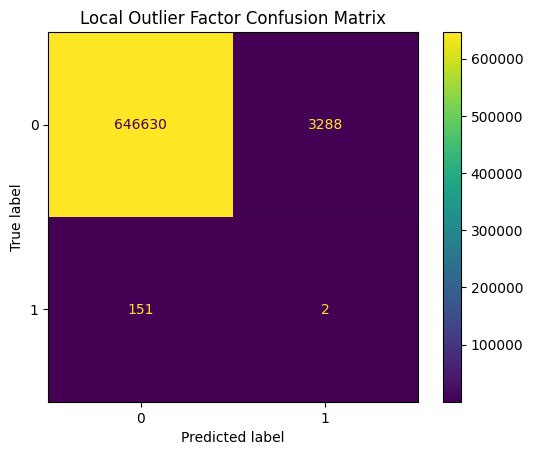

In [12]:
cm_lof = confusion_matrix(y_test, pred_lof)
disp_lof = ConfusionMatrixDisplay(confusion_matrix=cm_lof)
disp_lof.plot()
plt.title("Local Outlier Factor Confusion Matrix")
plt.show()

In [13]:
lof_f1_score = f1_score(y_test, pred_lof)
lof_accuracy = accuracy_score(y_test, pred_lof)
print(f"Local Outlier Factor F1 Score: {lof_f1_score:.4f}")
print(f"Local Outlier Factor Accuracy: {lof_accuracy:.4f}")

Local Outlier Factor F1 Score: 0.0012
Local Outlier Factor Accuracy: 0.9947


### XGBoost

In [15]:
base_xgb = XGBClassifier(
    random_state=14,
    objective="binary:logistic",
    learning_rate=0.1,
    max_depth=3,
)

gscv_xgb = GridSearchCV(
    estimator=base_xgb,
    param_grid={
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.05, 0.1],
        "scale_pos_weight": [100, 500, 1000],
    },
    scoring="f1",
    cv=3,
)

gscv_xgb.fit(X_train_prepared, y_train)
xgb = gscv_xgb.best_estimator_
pred_xgb = xgb.predict(X_test_prepared)

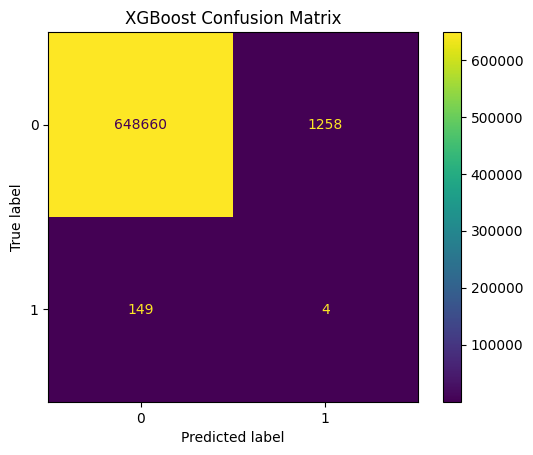

In [16]:
cm_xgb = confusion_matrix(y_test, pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [17]:
xgb_f1_score = f1_score(y_test, pred_xgb)
xgb_accuracy = accuracy_score(y_test, pred_xgb)
print(f"XGBoost F1 Score: {xgb_f1_score:.4f}")
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

XGBoost F1 Score: 0.0057
XGBoost Accuracy: 0.9978


### Neural Network

In [42]:
nn = Sequential()
nn.add(Dense(16, activation="relu"))
nn.add(Dense(8, activation="relu"))
nn.add(Dense(1, activation="sigmoid"))

nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

nn.fit(
    X_train_prepared,
    y_train,
    epochs=10,
    batch_size=1024,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=2, restore_best_weights=True, min_delta=0.05, monitor="loss"
        )
    ],
)

nn_preds = (nn.predict(X_test_prepared) > 0.5).astype(int)

Epoch 1/10
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9962 - loss: 0.0280
Epoch 2/10
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9998 - loss: 0.0023
Epoch 3/10
2540/2540 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9998 - loss: 0.0022
20315/20315 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step


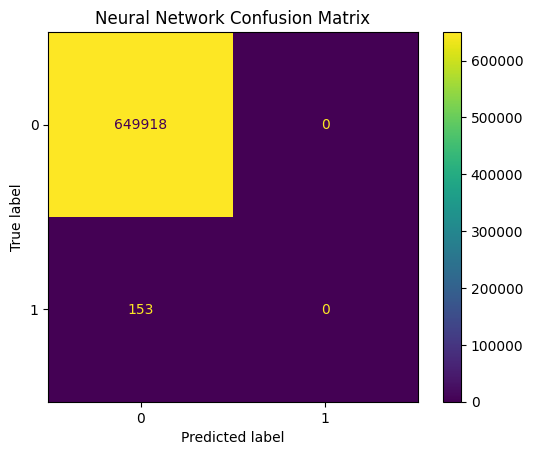

In [43]:
nn_cm = confusion_matrix(y_test, nn_preds)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=nn_cm)
disp_nn.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

In [44]:
nn_sm = Sequential()
nn_sm.add(Dense(16, activation="relu"))
nn_sm.add(Dense(8, activation="relu"))
nn_sm.add(Dense(1, activation="sigmoid"))

nn_sm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

nn_sm.fit(
    X_train_sm_prepared,
    y_train_sm,
    epochs=10,
    batch_size=1024,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=2, restore_best_weights=True, min_delta=0.05, monitor="loss"
        )
    ],
)

nn_sm_preds = (nn_sm.predict(X_test_sm_prepared) > 0.5).astype(int)

Epoch 1/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6727 - loss: 0.6028
Epoch 2/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.6746 - loss: 0.5950
Epoch 3/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.6783 - loss: 0.5921
20315/20315 ━━━━━━━━━━━━━━━━━━━━ 68s 3ms/step


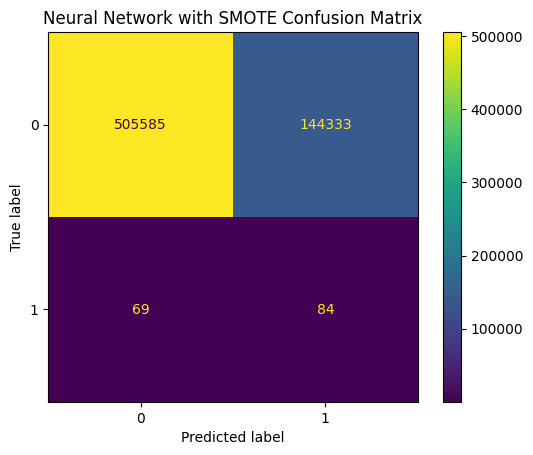

In [45]:
nn_cm_sm = confusion_matrix(y_test, nn_sm_preds)
disp_nn_sm = ConfusionMatrixDisplay(confusion_matrix=nn_cm_sm)
disp_nn_sm.plot()
plt.title("Neural Network with SMOTE Confusion Matrix")
plt.show()

In [46]:
nn_bsm = Sequential()
nn_bsm.add(Dense(16, activation="relu"))
nn_bsm.add(Dense(8, activation="relu"))
nn_bsm.add(Dense(1, activation="sigmoid"))

nn_bsm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

nn_bsm.fit(
    X_train_bsm_prepared,
    y_train_bsm,
    epochs=10,
    batch_size=1024,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=2, restore_best_weights=True, min_delta=0.05, monitor="loss"
        )
    ],
)

nn_bsm_preds = (nn_bsm.predict(X_test_bsm_prepared) > 0.5).astype(int)

Epoch 1/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 38s 6ms/step - accuracy: 0.9713 - loss: 0.0898
Epoch 2/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9907 - loss: 0.0417
Epoch 3/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step - accuracy: 0.9928 - loss: 0.0318
Epoch 4/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - accuracy: 0.9941 - loss: 0.0269
Epoch 5/10
5078/5078 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.9949 - loss: 0.0245
20315/20315 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step


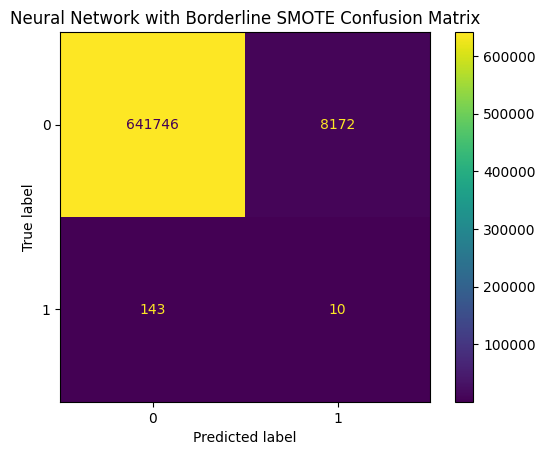

In [47]:
nn_bsm_cm = confusion_matrix(y_test, nn_bsm_preds)
disp_nn_bsm = ConfusionMatrixDisplay(confusion_matrix=nn_bsm_cm)
disp_nn_bsm.plot()
plt.title("Neural Network with Borderline SMOTE Confusion Matrix")
plt.show()

In [48]:
nn_f1_score = f1_score(y_test, nn_bsm_preds)
nn_sm_f1_score = f1_score(y_test, nn_sm_preds)
nn_bsm_f1_score = f1_score(y_test, nn_bsm_preds)
print(f"Neural Network F1 Score: {nn_f1_score:.4f}")
print(f"Neural Network with SMOTE F1 Score: {nn_sm_f1_score:.4f}")
print(f"Neural Network with Borderline SMOTE F1 Score: {nn_bsm_f1_score:.4f}")

Neural Network F1 Score: 0.0024
Neural Network with SMOTE F1 Score: 0.0012
Neural Network with Borderline SMOTE F1 Score: 0.0024


### Conclusion

The best performing model based on F1 score was the XGBoost algorithm.

In [18]:
pkl.dump(xgb, open("../../../models/down_syndrome/xgb_model.pkl", "wb"))